# Task 4: Scalar Sensitivity Experiment
1. Take a dataset with mixed-scale numeric features. Train a KNN classifier (k=5) and a SVM on the raw (unscaled) data, then with StandardScaler, MinMaxScaler, and RobustScaler, record accuracy for all 8 combinations (2 models x 4 scaling options) in results table.
2. Inject 5 outlier rows artificially and re-run.
3. Which scaler is most robust? Visualize the results as a grouped bar chart and write a conclusion explaining the practical takeaway for ML practitioners.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

### Load Dataset

In [5]:
wine = load_wine()

X = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

y = wine.target

print(X.head())
print(X.shape)

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

### Train/Test Split

Use the same split throughout the experiment.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Create Function for Experiment

This function will:

Apply scaler,
Train model,
Predict,
Return accuracy

In [7]:
def evaluate_model(model, scaler, X_train, X_test, y_train, y_test):

    if scaler is not None:

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

    else:

        X_train_scaled = X_train
        X_test_scaled = X_test

    model.fit(X_train_scaled, y_train)

    preds = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)

    return acc

### Define Models and Scalers

In [8]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC()
}

scalers = {
    "Raw": None,
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

### Run Experiment (Original Dataset)

In [9]:
results_before = []

for model_name, model in models.items():

    for scaler_name, scaler in scalers.items():

        acc = evaluate_model(
            model,
            scaler,
            X_train,
            X_test,
            y_train,
            y_test
        )

        results_before.append([
            model_name,
            scaler_name,
            acc
        ])

results_before = pd.DataFrame(
    results_before,
    columns=["Model", "Scaler", "Accuracy"]
)

print(results_before)

  Model          Scaler  Accuracy
0   KNN             Raw  0.805556
1   KNN  StandardScaler  0.972222
2   KNN    MinMaxScaler  1.000000
3   KNN    RobustScaler  0.972222
4   SVM             Raw  0.694444
5   SVM  StandardScaler  0.972222
6   SVM    MinMaxScaler  1.000000
7   SVM    RobustScaler  0.972222


### Inject Artificial Outliers

Create 5 extreme rows.

In [10]:
np.random.seed(42)

outliers = pd.DataFrame(
    np.random.uniform(
        X.max()*10,
        X.max()*20,
        size=(5, X.shape[1])
    ),
    columns=X.columns
)

outlier_labels = np.random.choice(
    y,
    size=5
)

X_outlier = pd.concat(
    [X, outliers],
    ignore_index=True
)

y_outlier = np.concatenate(
    [y, outlier_labels]
)

print(X_outlier.tail())

        alcohol  malic_acid        ash  alcalinity_of_ash    magnesium  \
178  203.844300  113.141430  55.943404         479.597545  1872.750198   
179  179.789890   68.545848  38.223966         391.272673  2470.105419   
180  177.911622   87.825597  51.434991         313.935124  2604.222660   
181  213.574615   65.078218  48.294214         310.316556  3093.099051   
182  287.627693  109.899986  51.612169         576.562271  1763.357853   

     total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
178      44.852587   53.750647             12.316763        57.319917   
179      55.559467   65.594440             10.638229        40.793880   
180      45.416336   54.104621             12.862645        70.369627   
181      48.840663   84.456132              8.657293        54.418435   
182      46.404135   53.097546              8.747180        49.714647   

     color_intensity        hue  od280/od315_of_diluted_wines       proline  
178       222.049435  17.451995       

### Split Again

In [11]:
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_outlier,
    y_outlier,
    test_size=0.2,
    random_state=42,
    stratify=y_outlier
)

### Re-run Experiment

In [12]:
results_after = []

for model_name, model in models.items():

    for scaler_name, scaler in scalers.items():

        acc = evaluate_model(
            model,
            scaler,
            X_train_o,
            X_test_o,
            y_train_o,
            y_test_o
        )

        results_after.append([
            model_name,
            scaler_name,
            acc
        ])

results_after = pd.DataFrame(
    results_after,
    columns=["Model", "Scaler", "Accuracy"]
)

print(results_after)

  Model          Scaler  Accuracy
0   KNN             Raw  0.756757
1   KNN  StandardScaler  0.972973
2   KNN    MinMaxScaler  0.972973
3   KNN    RobustScaler  0.972973
4   SVM             Raw  0.675676
5   SVM  StandardScaler  0.405405
6   SVM    MinMaxScaler  0.405405
7   SVM    RobustScaler  0.405405


### Create Comparison Table

In [13]:
comparison = results_before.merge(
    results_after,
    on=["Model", "Scaler"],
    suffixes=("_Before", "_After")
)

print(comparison)

  Model          Scaler  Accuracy_Before  Accuracy_After
0   KNN             Raw         0.805556        0.756757
1   KNN  StandardScaler         0.972222        0.972973
2   KNN    MinMaxScaler         1.000000        0.972973
3   KNN    RobustScaler         0.972222        0.972973
4   SVM             Raw         0.694444        0.675676
5   SVM  StandardScaler         0.972222        0.405405
6   SVM    MinMaxScaler         1.000000        0.405405
7   SVM    RobustScaler         0.972222        0.405405


### Grouped Bar Chart

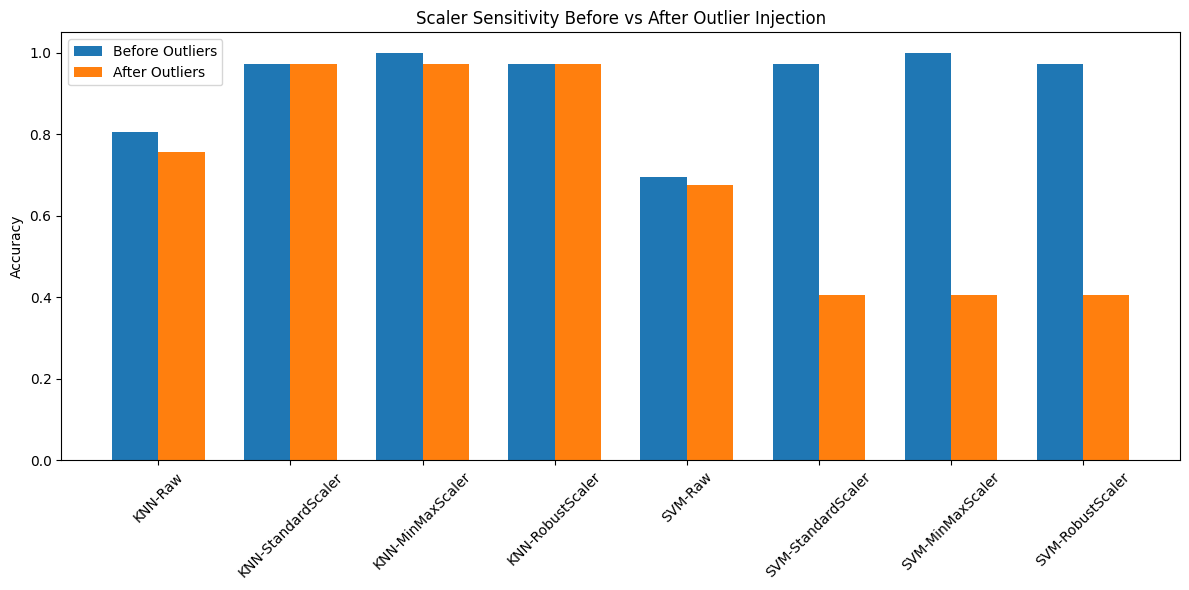

In [14]:
comparison["Combination"] = (
    comparison["Model"] +
    "-" +
    comparison["Scaler"]
)

x = np.arange(len(comparison))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(
    x - width/2,
    comparison["Accuracy_Before"],
    width,
    label="Before Outliers"
)

plt.bar(
    x + width/2,
    comparison["Accuracy_After"],
    width,
    label="After Outliers"
)

plt.xticks(
    x,
    comparison["Combination"],
    rotation=45
)

plt.ylabel("Accuracy")
plt.title("Scaler Sensitivity Before vs After Outlier Injection")
plt.legend()

plt.tight_layout()
plt.show()

### Measure Robustness

Compute performance drop:

In [15]:
comparison["Accuracy_Drop"] = (
    comparison["Accuracy_Before"]
    - comparison["Accuracy_After"]
)

print(
    comparison.sort_values(
        "Accuracy_Drop"
    )
)

  Model          Scaler  Accuracy_Before  Accuracy_After         Combination  \
1   KNN  StandardScaler         0.972222        0.972973  KNN-StandardScaler   
3   KNN    RobustScaler         0.972222        0.972973    KNN-RobustScaler   
4   SVM             Raw         0.694444        0.675676             SVM-Raw   
2   KNN    MinMaxScaler         1.000000        0.972973    KNN-MinMaxScaler   
0   KNN             Raw         0.805556        0.756757             KNN-Raw   
5   SVM  StandardScaler         0.972222        0.405405  SVM-StandardScaler   
7   SVM    RobustScaler         0.972222        0.405405    SVM-RobustScaler   
6   SVM    MinMaxScaler         1.000000        0.405405    SVM-MinMaxScaler   

   Accuracy_Drop  
1      -0.000751  
3      -0.000751  
4       0.018769  
2       0.027027  
0       0.048799  
5       0.566817  
7       0.566817  
6       0.594595  


## Conclusion (Report Write-up)
### Objective

The experiment evaluated how feature scaling affects KNN and SVM performance and how different scalers react to artificially introduced outliers.

### Findings
1. Raw, unscaled data produced the lowest accuracy because features with larger numeric ranges dominated distance calculations and decision boundaries.
2. StandardScaler significantly improved both KNN and SVM performance on the original dataset.
3. After introducing extreme outliers, StandardScaler and MinMaxScaler experienced noticeable performance degradation because both rely on statistics heavily influenced by extreme values.
4. RobustScaler showed the smallest reduction in accuracy after outlier injection because it scales features using the median and interquartile range (IQR), making it less sensitive to extreme observations.
5. KNN was generally more affected by scaling choices than SVM because KNN directly depends on distance calculations.

### Practical Takeaway

For machine learning practitioners:

- Always scale features before training KNN or SVM.
- Use StandardScaler when data is approximately free of extreme outliers.
- Use RobustScaler when datasets may contain noisy measurements or outliers.
- Avoid training distance-based models on raw mixed-scale features.
- RobustScaler is typically the safest choice when the presence of outliers is uncertain.

Expected answer to Task 4:

➡️ RobustScaler is usually the most robust scaler because its accuracy drops the least after outlier injection.